# Projekt

## Promethee

Niniejszy projekt koncentruje się na analizie decyzyjnej w obrębie popularnej gry typu MOBA – League of Legends. Celem opracowania jest wielokryterialne wspomaganie wyboru optymalnego bohatera na pozycję ADC (Attack Damage Carry). W strukturze rozgrywki wyróżniamy pięć kluczowych ról: Top, Mid, Jungle, Support oraz ADC. Ta ostatnia pełni fundamentalną funkcję strategiczną – odpowiada za generowanie najwyższych obrażeń ciągłych, co w praktyce stanowi kluczowy czynnik determinujący zwycięstwo w starciach drużynowych.


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd

import utils
from utils import display_ranking

#Dataset

Zbiór danych składa się z postaci, które pojawiły się w 5 lub więcej meczach rundy 1 i 2 LCK w obecnym roku. Wybrano jedynie 12 wariantów, ale dokładanie innych, mogłoby wprowadzić szum do danych, ponieważ były grane w zaledwie kilku meczach i ich statystyki mogłyby być niemiarodajne

In [6]:
dataset = pd.read_csv('Alternatives.csv',index_col=0)
preference_information = pd.read_csv('Preferences_Promethee.csv',index_col=0)

In [7]:
dataset

,G1,G2,G3,G4,G5
Alternative,,,,,
Ashe,62,5.0,66,10.1,636
Caitlyn,60,3.3,153,10.3,759
Corki,50,4.1,-33,10.2,744
Ezreal,34,3.0,-86,10.2,757
Jhin,62,6.3,221,10.1,742
Lucian,40,2.0,232,9.8,855
Sivir,50,5.0,27,10.5,869
Yunara,42,2.8,-204,10.1,732
Miss Fortune,50,4.1,-300,10.7,832


Wybrano 5 kryteriów oceny.

G1 to Win% - procent meczy, w których przy wyborze danej postaci, drużyna zwyciężyła

G2 to KDA - stosunek (zabójstwa+asysty)/śmierci postaci

G3 to GD10 - posiadane złoto względem przeciwnego ADC do 10 minuty meczu

G4 to CSPM - średnia liczba zabitych stworów na minutę w meczu

G5 to DPM - średnie obrażenia zadawane na minutę w meczu




In [8]:
preference_information

,q,p,k,type
Criterion,,,,
G1,5.0,15.0,2,gain
G2,1.0,2.5,4,gain
G3,50.0,300.0,6,gain
G4,0.2,0.4,8,gain
G5,60.0,140.0,10,gain


### Funkcja obliczająca różnicę między alternatywami na danym kryterium





In [9]:

def difference_function(alternative_a: float, alternative_b: float, criterion_type: utils.CriterionType) -> float:
  if criterion_type == 'gain':
    return alternative_a - alternative_b
  else:
    return alternative_b - alternative_a



### Funkcja obliczająca wartość preferencji cząstkowej

z wzoru:
$$
    \pi_k (a, b) = \left\{ \begin{array}{ll}
    1, & \textrm{if } d_k(a, b) > p_k,\\
    0, & \textrm{if } d_k(a, b) \leq q_k,\\
    \frac{d_k(a, b) - q_k} {p_k - q_k}, & \textrm{if } q_k < d_k(a, b) \leq p_k.
    \end{array} \right.
$$

In [10]:

def marginal_preference_function(diff: float, indifference_threshold: float, preference_threshold: float) -> float:
    if diff <= indifference_threshold:
        return 0
    elif diff > preference_threshold:
        return 1
    else:
      return (diff - indifference_threshold) / (preference_threshold - indifference_threshold)


### Funkcja obliczająca wartości wszystkich preferencji marginalnych

In [11]:

def calculate_marginal_preference_matrix(dataset: pd.DataFrame, preference_information: pd.DataFrame) -> np.ndarray:
    n_alt = len(dataset)
    n_crit = len(dataset.columns)

    marginal_matrix = np.zeros((n_alt, n_alt, n_crit))

    for k_idx, criterion in enumerate(dataset.columns):
        c_info = preference_information.loc[criterion]

        for i in range(n_alt):
            for j in range(n_alt):
                if i == j:
                    continue

                diff = difference_function(dataset.iloc[i, k_idx], dataset.iloc[j, k_idx], c_info['type'])
                pref = marginal_preference_function(diff, c_info['q'], c_info['p'])

                marginal_matrix[i, j, k_idx] = pref

    return marginal_matrix


In [12]:
marginal_preference_matrix = calculate_marginal_preference_matrix(dataset, preference_information)

In [13]:
marginal_preference_matrix[4, 5]

array([1. , 1. , 0. , 0.5, 0. ])

### Funkcja obliczająca wartości preferencji cząstkowych dla wszystkich kryteriów z użyciem ich wag


z wzoru:

$$\pi(a, b) = \frac{\sum w_k * \pi_k(a, b)}{\sum w_k}$$

gdzie:
- $w_k$ to waga kryterium k,
- $\pi_k(a, b)$ to wartość preferencji marginalnej.

In [14]:
def calculate_comprehensive_preference_index(marginal_preference_matrix: np.ndarray, preference_information: pd.DataFrame) -> np.ndarray:
    l = []
    n_alt = len(dataset)
    for i in range (len(marginal_preference_matrix)):
      for j in range(len(marginal_preference_matrix[i])):
        l.append(np.sum(marginal_preference_matrix[i][j] * preference_information['k'])/np.sum(preference_information['k']))
    return np.array(l).reshape(n_alt,n_alt)


In [15]:
comprehensive_preference_index = calculate_comprehensive_preference_index(marginal_preference_matrix, preference_information)

In [16]:
comprehensive_preference_index

array([[0.00000000e+00, 6.22222222e-02, 8.58666667e-02, 2.37155556e-01,
        0.00000000e+00, 3.33333333e-01, 4.66666667e-02, 3.49333333e-01,
        2.46666667e-01, 4.06666667e-01, 3.08000000e-01, 8.88888889e-03],
       [2.92100000e-01, 0.00000000e+00, 1.42133333e-01, 2.17866667e-01,
        1.40628250e-15, 3.60000000e-01, 9.41333333e-02, 2.66666667e-01,
        2.33333333e-01, 4.66666667e-01, 4.17600000e-01, 0.00000000e+00],
       [2.00000000e-01, 0.00000000e+00, 0.00000000e+00, 7.79555556e-02,
        0.00000000e+00, 3.97777778e-01, 0.00000000e+00, 1.43466667e-01,
        1.73600000e-01, 3.27466667e-01, 2.66666667e-01, 0.00000000e+00],
       [2.54166667e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.66666667e-01, 0.00000000e+00, 5.44000000e-02,
        1.31200000e-01, 2.85066667e-01, 2.66666667e-01, 0.00000000e+00],
       [3.02333333e-01, 1.47733333e-01, 3.16533333e-01, 4.00000000e-01,
        0.00000000e+00, 3.33333333e-01, 1.88533333e-01, 4.00

### Funkcje do obliczania przepływów:

In [17]:
def calculate_positive_flow(comprehensive_preference_matrix: np.ndarray, alternatives: pd.Index) -> pd.Series:
    sums = np.sum(comprehensive_preference_matrix, axis=1)
    return pd.Series(sums, index=alternatives)


In [18]:
def calculate_negative_flow(comprehensive_preference_matrix: np.ndarray, alternatives: pd.Index) -> pd.Series:
    sums = np.sum(comprehensive_preference_matrix, axis=0)
    return pd.Series(sums, index=alternatives)


In [19]:
def calculate_net_flow(positive_flow: pd.Series, negative_flow: pd.Series) -> pd.Series:
    return positive_flow - negative_flow

In [20]:
positive_flow = calculate_positive_flow(comprehensive_preference_index, dataset.index)
negative_flow = calculate_negative_flow(comprehensive_preference_index, dataset.index)
net_flow = calculate_net_flow(positive_flow, negative_flow)

In [21]:
positive_flow

,0
Alternative,
Ashe,2.084800
Caitlyn,2.490500
Corki,1.586933
Ezreal,1.258167
Jhin,3.548644
Lucian,2.872000
Sivir,4.791300
Yunara,0.740133
Miss Fortune,3.511667


In [22]:
negative_flow

,0
Alternative,
Ashe,4.355000
Caitlyn,1.841211
Corki,2.692333
Ezreal,3.347189
Jhin,1.926111
Lucian,3.615278
Sivir,1.143967
Yunara,4.257222
Miss Fortune,2.612533


In [23]:
net_flow

,0
Alternative,
Ashe,-2.270200
Caitlyn,0.649289
Corki,-1.105400
Ezreal,-2.089022
Jhin,1.622533
Lucian,-0.743278
Sivir,3.647333
Yunara,-3.517089
Miss Fortune,0.899133


### Ranking częściowy




In [24]:
def create_partial_ranking(positive_flow: pd.Series, negative_flow: pd.Series) -> pd.DataFrame:
    n_alt = len(positive_flow)

    result_matrix = np.zeros((n_alt, n_alt), dtype=int)

    p_vals = positive_flow.values
    n_vals = negative_flow.values

    for i in range(n_alt):
        for j in range(n_alt):
            pi = p_vals[i]
            pj = p_vals[j]
            ni = n_vals[i]
            nj = n_vals[j]

            is_pref = (pi > pj and ni <= nj) or (pi == pj and ni < nj)

            is_indiff = (pi == pj and ni == nj)

            if is_pref or is_indiff:
                result_matrix[i, j] = 1

    df_final = pd.DataFrame(
        result_matrix,
        index=positive_flow.index,
        columns=positive_flow.index
    )

    return df_final


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,864 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,292 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,862 kB]


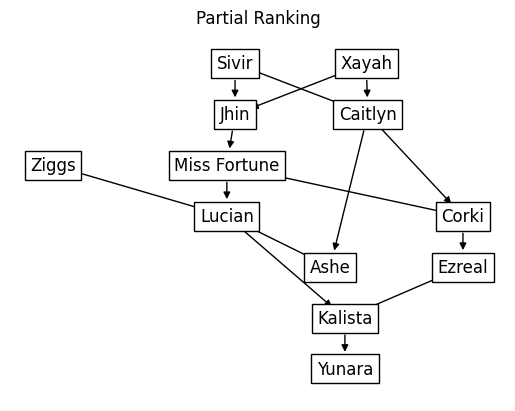

In [25]:

!apt-get update
!apt-get install graphviz graphviz-dev -y


!pip install pygraphviz
partial_ranking = create_partial_ranking(positive_flow, negative_flow)
display_ranking(partial_ranking, "Partial Ranking")

### Ranking kompletny

In [26]:
def create_complete_ranking(net_flow: pd.Series) -> pd.DataFrame:
    n_alt = len(positive_flow)
    result_matrix = np.zeros((n_alt, n_alt), dtype=int)

    vals = net_flow.values
    for i in range (n_alt):
        for j in range(n_alt):
            if vals[i] > vals[j]:
                result_matrix[i, j] = 1
    df_final = pd.DataFrame(
        result_matrix,
        index=positive_flow.index,
        columns=positive_flow.index
    )
    return df_final

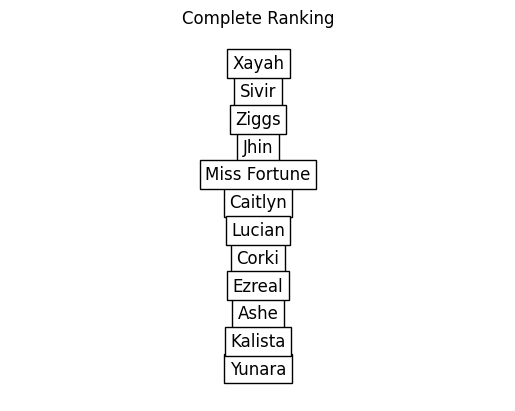

In [27]:
complete_ranking = create_complete_ranking(net_flow)
display_ranking(complete_ranking, "Complete Ranking")

# Electre III


In [28]:
preference_information = pd.read_csv('Preferences_Electre.csv',index_col=0)
preference_information = preference_information.rename(columns={'k': 'w'})

In [29]:
preference_information

,q,p,v,w,type
Criterion,,,,,
G1,5.0,15.0,45.0,2,gain
G2,1.0,2.5,5.0,4,gain
G3,50.0,300.0,500.0,6,gain
G4,0.2,0.4,1.0,8,gain
G5,60.0,140.0,320.0,10,gain


### Funkcja obliczająca różnicę między alternatywami na danym kryterium





In [30]:
def difference_function(alternative_a: float, alternative_b: float, criterion_type: utils.CriterionType) -> float:
    if criterion_type == 'gain':
        return alternative_a - alternative_b
    else:
        return alternative_b - alternative_a

### Funkcja obliczająca wartość cząstkowego współczynnika zgodności
z wzoru:
$$
c(a, b)=\begin{cases}
1, & d(a,b) \ge -q \\
0, & d(a,b) \le -p \\
\frac{p + d(a,b)}{p - q}, & -q > d(a,b) > -p
\end{cases}
$$

In [31]:
def calculate_marginal_concordance_index(diff: float, indifference_threshold: float, preference_threshold: float) -> float:
    if diff >= -indifference_threshold:
        return 1
    elif diff <= -preference_threshold:
        return 0
    else:
        return (preference_threshold + diff) / (preference_threshold - indifference_threshold)


### Funkcja do stworzenia tablicy ze wszystkimi wartościami cząstkowych współczynników zgodności

In [32]:
def calculate_marginal_concordance_matrix(dataset: pd.DataFrame, preference_information: pd.DataFrame) -> np.ndarray:
    n_alt = len(dataset)
    n_crit = len(dataset.columns)

    matrix = np.zeros((n_alt, n_alt, n_crit))

    for k_idx, criterion in enumerate(dataset.columns):
        c_info = preference_information.loc[criterion]
        for i in range(n_alt):
            for j in range(n_alt):
                if i == j:
                    continue
                diff = difference_function(dataset.iloc[i][criterion], dataset.iloc[j][criterion], c_info['type'])
                matrix[i, j, k_idx] = calculate_marginal_concordance_index(diff, c_info['q'], c_info['p'])
    return matrix

In [33]:
marginal_concordance_matrix = calculate_marginal_concordance_matrix(dataset, preference_information)

In [34]:
marginal_concordance_matrix[4, 0]

array([1., 1., 1., 1., 1.])

### Funkcja agregująca wartości cząstkowych współczynników zgodności dla pary na wszystkich kryteriach, z wykorzystaniem wag
z wzoru:
$$C(a, b) = \frac{\sum w_k * c_k(a, b)}{\sum w_k}$$

gdzie:
- $w_k$ to waga kryterium k,
- $c_k(a, b)$ to cząstkowy współczynnik zgodnośći.

In [35]:

def calculate_comprehensive_concordance_matrix(marginal_concordance_matrix: np.ndarray, preference_information: pd.DataFrame) -> np.ndarray:
    l = []
    n_alt = len(dataset)
    for i in range (len(marginal_concordance_matrix)):
      for j in range(len(marginal_concordance_matrix[i])):
        l.append(np.sum(marginal_concordance_matrix[i][j] * preference_information['w'])/np.sum(preference_information['w']))
    return np.array(l).reshape(n_alt,n_alt)

In [36]:
comprehensive_concordance_index = calculate_comprehensive_concordance_matrix(marginal_concordance_matrix, preference_information)

In [37]:
comprehensive_concordance_index

array([[0.        , 0.7079    , 0.8       , 0.74583333, 0.69766667,
        0.57386667, 0.4       , 0.85      , 0.4       , 0.46666667,
        0.66666667, 0.3364    ],
       [0.93777778, 0.        , 1.        , 1.        , 0.85226667,
        0.8268    , 0.72944444, 1.        , 0.67916667, 0.46666667,
        1.        , 0.66666667],
       [0.91413333, 0.85786667, 0.        , 1.        , 0.68346667,
        0.6155    , 0.58783333, 1.        , 0.61666667, 0.46666667,
        0.99166667, 0.57386667],
       [0.76284444, 0.78213333, 0.92204444, 0.        , 0.6       ,
        0.635     , 0.44404444, 0.98      , 0.59527778, 0.46666667,
        0.93333333, 0.53146667],
       [1.        , 1.        , 1.        , 1.        , 0.        ,
        0.77916667, 0.45416667, 1.        , 0.60833333, 0.58222222,
        0.98333333, 0.66666667],
       [0.66666667, 0.64      , 0.60222222, 0.73333333, 0.66666667,
        0.        , 0.56666667, 0.86666667, 0.60222222, 0.49583333,
        0.95777778,

### Funkcja obliczająca czastkowy współczynnik niezgodności

z wzoru:
$$
D_j (a_i, b_{h}) = \begin{cases}
    1, & d_k(a_{i}, b_{h}) \leq -v_j^h,\\
    0, & d_k(a_{i}, b_{h}) \geq -p_j^h,\\
    \frac{-d_k(a_{i}, b_{h}) - p_j^h}{v_j^h - p_j^h}, & -p_j^h > d_k(a_{i}, b_{h}) > -v_j^h.
\end{cases}
$$

In [38]:

def calculate_marginal_discordance_index(diff: float, preference_threshold: float, veto_threshold: float) -> float:
    if diff <= -veto_threshold:
        return 1
    elif diff >= -preference_threshold:
        return 0
    else:
        return (-diff - preference_threshold) / (veto_threshold - preference_threshold)

### Funkcja wyliczająca tablicę ze wszystkimi wartościami cząstkowych współczynników zgodności

In [39]:

def calculate_marginal_discordance_matrix(dataset: pd.DataFrame, preference_information: pd.DataFrame) -> np.ndarray:
    n_alt = len(dataset)
    n_crit = len(dataset.columns)
    matrix = np.zeros((n_alt, n_alt, n_crit))
    for k_idx, criterion in enumerate(dataset.columns):
        c_info = preference_information.loc[criterion]
        for i in range(n_alt):
            for j in range(n_alt):
                if i == j:
                    continue
                diff = difference_function(dataset.iloc[i][criterion], dataset.iloc[j][criterion], c_info['type'])
                matrix[i, j, k_idx] = calculate_marginal_discordance_index(diff, c_info['p'], c_info['v'])
    return matrix

In [40]:
marginal_discordance_index = calculate_marginal_discordance_matrix(dataset, preference_information)

In [41]:
marginal_discordance_index[4,0]

array([0., 0., 0., 0., 0.])

###Funkcja agregująca wartości globalnego współczynnika zgodności z wartościami cząstkowych współczynników nie zgodności

z wzoru:
$$\sigma(a, b) = C(a, b) \cdot \prod_{d_k(a, b) > C(a, b)} \frac{1 - d_k(a, b)}{1 - C(a, b)}$$

gdzie:
- $C(a, b)$ to kompleksowy indeks zgodności,
- $d_k(a, b)$ to marginalna wartość niezgodności dla kryterium k,
- iloczyn jest liczony dla kryteriów, gdzie niezgodność przewyższa zgodność.

In [42]:

def calculate_credibility_index(comprehensive_concordance_matrix: np.ndarray, marginal_discordance_matrix: np.ndarray) -> np.ndarray:
    credibility_index = np.zeros(comprehensive_concordance_matrix.shape)
    for i in range(len(comprehensive_concordance_matrix)):
        for j in range(len(comprehensive_concordance_matrix[i])):
            if i == j:
                continue

            C = comprehensive_concordance_matrix[i, j]
            D_array = marginal_discordance_matrix[i][j]

            mask = D_array > C

            if not np.any(mask):
                credibility_index[i, j] = C
            else:
                if C == 1.0:
                    credibility_index[i, j] = 0.0
                else:
                    iloczyn = np.prod((1.0 - D_array[mask]) / (1.0 - C))
                    credibility_index[i, j] = C * iloczyn
    return credibility_index

In [43]:
comprehensive_credibility_index = calculate_credibility_index(comprehensive_concordance_index, marginal_discordance_index)

In [44]:
comprehensive_credibility_index

array([[0.        , 0.7079    , 0.8       , 0.74583333, 0.69766667,
        0.57386667, 0.32222222, 0.85      , 0.4       , 0.        ,
        0.66666667, 0.25346594],
       [0.93777778, 0.        , 1.        , 1.        , 0.85226667,
        0.8268    , 0.72944444, 1.        , 0.67916667, 0.26541667,
        1.        , 0.66666667],
       [0.91413333, 0.85786667, 0.        , 1.        , 0.68346667,
        0.6155    , 0.58783333, 1.        , 0.61666667, 0.27708333,
        0.99166667, 0.57386667],
       [0.76284444, 0.78213333, 0.92204444, 0.        , 0.6       ,
        0.635     , 0.44404444, 0.98      , 0.59527778, 0.        ,
        0.93333333, 0.        ],
       [1.        , 1.        , 1.        , 1.        , 0.        ,
        0.77916667, 0.45416667, 1.        , 0.60833333, 0.57293144,
        0.98333333, 0.66666667],
       [0.66666667, 0.64      , 0.60222222, 0.73333333, 0.56      ,
        0.        , 0.56666667, 0.86666667, 0.25232775, 0.        ,
        0.95777778,

###Procedura destylacji

In [45]:
@np.vectorize
def s(x: float, alpha: float, beta: float) -> float:
    return alpha * x + beta

In [46]:

def compute_lower_threshold(credibility: pd.DataFrame, upper_threshold: float, alpha: float, beta: float) -> float:
    s_val = (alpha * upper_threshold) + beta
    cutoff = upper_threshold - s_val
    sigma_values = credibility.to_numpy().flatten()
    valid_sigmas = sigma_values[sigma_values < cutoff]
    if len(valid_sigmas) > 0:
        return float(max(np.max(valid_sigmas), 0.0))
    else:
        return 0.0

### Macierz relacji przewyższania

In [47]:

def select_subset(
        credibility: pd.DataFrame,
        lower_threshold: float,
        alpha: float=-0.15,
        beta: float=0.3,
) -> list[str]:
    sigma = credibility.to_numpy()
    sigma_T = sigma.T
    s_val = alpha * sigma + beta

    cond1 = sigma > lower_threshold
    cond2 = sigma > (sigma_T + s_val)

    S = cond1 & cond2

    p_a = np.sum(S, axis=1)

    f_a = np.sum(S, axis=0)

    q_a = p_a - f_a

    max_quality = np.max(q_a)

    best_indices = np.where(q_a == max_quality)[0]

    best_alternatives = credibility.index[best_indices].astype(str).tolist()

    return best_alternatives


### Destylacja stępująca

In [48]:

def descending_distillation(credibility_index: np.ndarray, alternatives: pd.Index, alpha: float=-0.15, beta: float=0.3) -> pd.DataFrame:
    df_cred = pd.DataFrame(credibility_index, index=alternatives, columns=alternatives)
    A = list(alternatives)
    ranking_classes = []

    while len(A) > 0:
        sub_df_A = df_cred.loc[A, A]
        if len(A) > 1:
            vals = sub_df_A.values[~np.eye(len(sub_df_A), dtype=bool)]
            lambda_max = np.max(vals)
        else:
            lambda_max = 0

        lambda_val = compute_lower_threshold(sub_df_A, lambda_max, alpha, beta)
        B = select_subset(sub_df_A, lambda_val, alpha, beta)

        while len(B) > 1:
            prev_B = list(B)
            lambda_val = compute_lower_threshold(sub_df_A, lambda_val, alpha, beta)
            sub_df_B = df_cred.loc[B, B]
            B = select_subset(sub_df_B, lambda_val, alpha, beta)

            if set(B) == set(prev_B) or lambda_val <= 0:
                break

        ranking_classes.append(B)
        A = [x for x in A if x not in B]


    res = pd.DataFrame(0, index=alternatives, columns=alternatives)
    for i, class_i in enumerate(ranking_classes):
        for j, class_j in enumerate(ranking_classes):
            if i <= j:
                for a_i in class_i:
                    for a_j in class_j:
                        res.loc[a_i, a_j] = 1
    return res




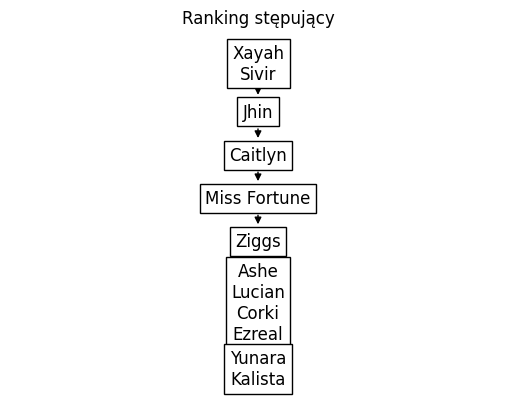

In [49]:

descending_ranking = descending_distillation(
    comprehensive_credibility_index,
    dataset.index,
)
utils.display_ranking(descending_ranking, "Ranking stępujący")

###Destylacja wstępująca

In [50]:
def ascending_distillation(credibility_index: np.ndarray, alternatives: pd.Index, alpha: float=-0.15, beta: float=0.3) -> pd.DataFrame:
    return descending_distillation(credibility_index.T, alternatives, alpha, beta).T

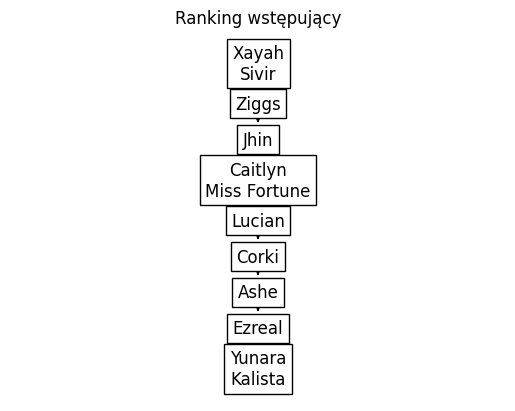

In [51]:
ascending_ranking = ascending_distillation(
    comprehensive_credibility_index,
    dataset.index,
)
utils.display_ranking(ascending_ranking, "Ranking wstępujący")

###Ostateczny ranking

In [52]:
# TODO
def create_final_ranking(descending_ranking: pd.DataFrame, ascending_ranking: pd.DataFrame) -> pd.DataFrame:
    final_matrix = descending_ranking * ascending_ranking
    return final_matrix

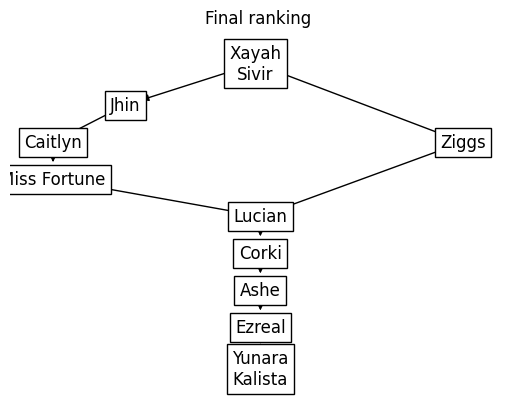

In [53]:
final_ranking = create_final_ranking(descending_ranking, ascending_ranking)
utils.display_ranking(final_ranking, "Final ranking")